# Perhitungan Buffer Stock

Notebook ini menghitung buffer stock berdasarkan dataset penjualan dengan rumus:

**Buffer Stock = (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)**

Dimana:
- **Max Daily Sales**: Penjualan harian maksimum (jumlah barang tertinggi dalam 1 hari)
- **Max Lead Time**: Lead time maksimum yang mungkin terjadi
- **Avg Daily Sales**: Rata-rata penjualan harian
- **Avg Lead Time**: Rata-rata lead time normal


## 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Dataset

In [3]:
# Load dataset
file_path = 'Dataset_Forecasting_ARIMA_Lengkap.xlsx'
dataset = pd.read_excel(file_path)

# Tampilkan beberapa baris pertama
print("Dataset Info:")
print(dataset.head())
print("\nJumlah data:", len(dataset))
print("\nKolom dataset:", dataset.columns.tolist())

Dataset Info:
                  Date  AERIS10  BB 10  BB 30  BR45  BR75   CC   CNF  CNF 10  \
0  2025-01-01 00:00:00      0.0    0.0    0.0   0.0   0.0  0.0   0.0     0.0   
1  2025-01-02 00:00:00      0.0    0.0    1.0   0.0   0.0  0.0   3.0    14.0   
2  2025-01-03 00:00:00      0.0    1.0    0.0   0.0   0.0  0.0  18.0    45.0   
3  2025-01-04 00:00:00      0.0    0.0    0.0   0.0   0.0  0.0   8.0     4.0   
4  2025-01-05 00:00:00      0.0    0.0    0.0   0.0   0.0  0.0   0.0     0.0   

   CNF 100  ...  MYB  MYB 10  MYB 100   NB   TC  TC 10  TC 250  TEETH10   TP  \
0      0.0  ...  0.0     0.0      0.0  0.0  0.0    0.0     0.0      0.0  0.0   
1      0.0  ...  0.0     3.0      0.0  0.0  0.0    1.0     0.0      0.0  0.0   
2      0.0  ...  0.0     0.0      0.0  2.0  3.0    6.0     1.0      0.0  0.0   
3      0.0  ...  0.0     0.0      0.0  0.0  0.0    0.0     0.0      0.0  0.0   
4      0.0  ...  0.0     0.0      0.0  0.0  0.0    0.0     0.0      0.0  0.0   

   Total_Sales  
0      

## 3. Preprocessing Data

In [4]:
# Convert Date column ke datetime format (coerce invalid values to NaT)
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')

# Drop rows where Date could not be parsed (e.g. summary/header rows)
invalid_dates = dataset['Date'].isna().sum()
if invalid_dates > 0:
    print(f"⚠️ Menghapus {invalid_dates} baris dengan nilai tanggal tidak valid")
    dataset = dataset.dropna(subset=['Date'])

# Sort berdasarkan tanggal
dataset = dataset.sort_values('Date')

# Reset index
dataset = dataset.reset_index(drop=True)

print("Data setelah preprocessing:")
print(dataset.head())
print("\nRentang Tanggal:")
print(f"Tanggal Awal: {dataset['Date'].min()}")
print(f"Tanggal Akhir: {dataset['Date'].max()}")


⚠️ Menghapus 5 baris dengan nilai tanggal tidak valid
Data setelah preprocessing:
        Date  AERIS10  BB 10  BB 30  BR45  BR75   CC   CNF  CNF 10  CNF 100  \
0 2025-01-01      0.0    0.0    0.0   0.0   0.0  0.0   0.0     0.0      0.0   
1 2025-01-02      0.0    0.0    1.0   0.0   0.0  0.0   3.0    14.0      0.0   
2 2025-01-03      0.0    1.0    0.0   0.0   0.0  0.0  18.0    45.0      0.0   
3 2025-01-04      0.0    0.0    0.0   0.0   0.0  0.0   8.0     4.0      0.0   
4 2025-01-05      0.0    0.0    0.0   0.0   0.0  0.0   0.0     0.0      0.0   

   ...  MYB  MYB 10  MYB 100   NB   TC  TC 10  TC 250  TEETH10   TP  \
0  ...  0.0     0.0      0.0  0.0  0.0    0.0     0.0      0.0  0.0   
1  ...  0.0     3.0      0.0  0.0  0.0    1.0     0.0      0.0  0.0   
2  ...  0.0     0.0      0.0  2.0  3.0    6.0     1.0      0.0  0.0   
3  ...  0.0     0.0      0.0  0.0  0.0    0.0     0.0      0.0  0.0   
4  ...  0.0     0.0      0.0  0.0  0.0    0.0     0.0      0.0  0.0   

   Total_Sales  

## 4. Identifikasi Kolom Produk

In [5]:
# Identifikasi kolom produk (semua kolom kecuali Date dan Total_Sales)
product_columns = [col for col in dataset.columns if col not in ['Date', 'Total_Sales']]

print("=" * 60)
print("DAFTAR PRODUK YANG AKAN DIANALISIS")
print("=" * 60)
print(f"Jumlah produk: {len(product_columns)}")
print(f"\nProduk: {', '.join(product_columns)}")
print("=" * 60)

DAFTAR PRODUK YANG AKAN DIANALISIS
Jumlah produk: 37

Produk: AERIS10, BB 10, BB 30, BR45, BR75, CC, CNF, CNF 10, CNF 100, CNF 250, DS, DS 10, DS 100, DS 250, EC45, EC75, GF, GF 10, GF 250, IB, IB 10, IB 100, JOY, JOY 10, JOY 100, LDR, LDR 10, LDR 250, MYB, MYB 10, MYB 100, NB, TC, TC 10, TC 250, TEETH10, TP


## 5. Hitung Statistik Pemakaian Harian per Produk

In [12]:

# Hitung statistik untuk setiap produk
product_stats = pd.DataFrame()

for product in product_columns:
    stats = {
        'Produk': product,
        'Pemakaian_Maksimum': dataset[product].quantile(0.95),  # Persentil ke-95, tahan outlier
        'Pemakaian_Rata_rata': dataset[product].mean(),
        'Standar_Deviasi': dataset[product].std()
    }
    product_stats = pd.concat([product_stats, pd.DataFrame([stats])], ignore_index=True)

print("=" * 80)
print("STATISTIK PEMAKAIAN HARIAN PER PRODUK")
print("=" * 80)
print(product_stats.to_string(index=False))
print("=" * 80)

# Tampilkan top 5 produk berdasarkan pemakaian rata-rata
print("\nTOP 5 PRODUK BERDASARKAN PEMAKAIAN RATA-RATA:")
print(product_stats.nlargest(5, 'Pemakaian_Rata_rata')[['Produk', 'Pemakaian_Rata_rata', 'Pemakaian_Maksimum']].to_string(index=False))


STATISTIK PEMAKAIAN HARIAN PER PRODUK
 Produk  Pemakaian_Maksimum  Pemakaian_Rata_rata  Standar_Deviasi
AERIS10                 0.0             0.008219         0.116912
  BB 10                 1.0             0.126027         0.663413
  BB 30                 0.0             0.063014         0.376328
   BR45                 0.0             0.054795         0.366541
   BR75                 0.0             0.002740         0.052342
     CC                 1.0             0.339726         1.667295
    CNF                20.0             4.479452        10.660739
 CNF 10                23.4             4.397260        12.948482
CNF 100                 0.0             0.016438         0.127329
CNF 250                 0.0             0.002740         0.052342
     DS                 3.0             0.676712         2.683820
  DS 10                 4.0             0.800000         2.457552
 DS 100                 0.0             0.013699         0.116396
 DS 250                 0.0           

## 6. Definisi Lead Time

In [7]:
# Definisi Lead Time
avg_lead_time = 5.4   # hari (rata-rata)
max_lead_time = 7     # hari (maksimum / worst case)

print("=" * 60)
print("KOMPONEN LEAD TIME")
print("=" * 60)
print(f"  Avg Lead Time (Normal)      : {avg_lead_time} hari")
print(f"  Max Lead Time (Worst Case)  : {max_lead_time} hari")
print("=" * 60)


KOMPONEN LEAD TIME
  Avg Lead Time (Normal)      : 5.4 hari
  Max Lead Time (Worst Case)  : 7 hari


## 7. Perhitungan Buffer Stock per Produk

**Rumus:** `Buffer Stock = (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)`


In [13]:

# Hitung Buffer Stock untuk setiap produk menggunakan rumus:
# Buffer Stock = (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)

# Pastikan Pemakaian_Maksimum selalu >= Pemakaian_Rata_rata (hindari buffer negatif)
product_stats['Pemakaian_Maksimum'] = product_stats[['Pemakaian_Maksimum', 'Pemakaian_Rata_rata']].max(axis=1)

product_stats['Buffer_Stock'] = (
    (product_stats['Pemakaian_Maksimum'] * max_lead_time) -
    (product_stats['Pemakaian_Rata_rata'] * avg_lead_time)
).clip(lower=0)  # Buffer stock tidak boleh negatif

print("=" * 90)
print("PERHITUNGAN BUFFER STOCK PER PRODUK")
print("=" * 90)
print(f"Rumus: (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)")
print(f"       Max Lead Time = {max_lead_time} hari | Avg Lead Time = {avg_lead_time} hari")
print(f"       Max Daily Sales = max(Persentil-95, Rata-rata) → Tidak ada nilai negatif")
print("=" * 90)
print(product_stats[['Produk', 'Pemakaian_Maksimum', 'Pemakaian_Rata_rata', 'Buffer_Stock']].to_string(index=False))
print("=" * 90)

# Tampilkan produk dengan buffer stock tertinggi
print("\n📦 TOP 10 PRODUK DENGAN BUFFER STOCK TERTINGGI:")
print(product_stats.nlargest(10, 'Buffer_Stock')[['Produk', 'Pemakaian_Maksimum', 'Pemakaian_Rata_rata', 'Buffer_Stock']].to_string(index=False))


PERHITUNGAN BUFFER STOCK PER PRODUK
Rumus: (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)
       Max Lead Time = 7 hari | Avg Lead Time = 5.4 hari
       Max Daily Sales = max(Persentil-95, Rata-rata) → Tidak ada nilai negatif
 Produk  Pemakaian_Maksimum  Pemakaian_Rata_rata  Buffer_Stock
AERIS10            0.008219             0.008219      0.013151
  BB 10            1.000000             0.126027      6.319452
  BB 30            0.063014             0.063014      0.100822
   BR45            0.054795             0.054795      0.087671
   BR75            0.002740             0.002740      0.004384
     CC            1.000000             0.339726      5.165479
    CNF           20.000000             4.479452    115.810959
 CNF 10           23.400000             4.397260    140.054795
CNF 100            0.016438             0.016438      0.026301
CNF 250            0.002740             0.002740      0.004384
     DS            3.000000             0.676712     17.3

## 8. Safety Stock per Produk (Perhitungan Tambahan)

Sebagai perbandingan, kita juga dapat menghitung Safety Stock menggunakan metode standar deviasi:

**Safety Stock = Z-score × Standard Deviation × √Lead Time**

Dimana Z-score untuk service level 95% = 1.65

In [16]:
# Hitung Safety Stock untuk setiap produk (metode alternatif)
z_score = 1.65  # untuk service level 95%
product_stats['Safety_Stock_95%'] = z_score * product_stats['Standar_Deviasi'] * np.sqrt(avg_lead_time)

print("=" * 80)
print("PERHITUNGAN SAFETY STOCK PER PRODUK (Service Level 95%)")
print("=" * 80)
print(f"Z-score: {z_score} | √Avg Lead Time: {np.sqrt(avg_lead_time):.4f}")
print("=" * 80)
print(product_stats[['Produk', 'Standar_Deviasi', 'Safety_Stock_95%']].to_string(index=False))
print("=" * 80)

# Perbandingan Buffer Stock vs Safety Stock
comparison_df = product_stats.nlargest(10, 'Buffer_Stock')[['Produk', 'Buffer_Stock', 'Safety_Stock_95%']]
print("\n📊 PERBANDINGAN BUFFER STOCK vs SAFETY STOCK (Top 10):")
print(comparison_df.to_string(index=False))


PERHITUNGAN SAFETY STOCK PER PRODUK (Service Level 95%)
Z-score: 1.65 | √Avg Lead Time: 2.3238
 Produk  Standar_Deviasi  Safety_Stock_95%
AERIS10         0.116912          0.448272
  BB 10         0.663413          2.543695
  BB 30         0.376328          1.442937
   BR45         0.366541          1.405409
   BR75         0.052342          0.200694
     CC         1.667295          6.392833
    CNF        10.660739         40.875977
 CNF 10        12.948482         49.647762
CNF 100         0.127329          0.488210
CNF 250         0.052342          0.200694
     DS         2.683820         10.290447
  DS 10         2.457552          9.422876
 DS 100         0.116396          0.446293
 DS 250         0.090410          0.346656
   EC45         0.449513          1.723548
   EC75         0.052342          0.200694
     GF         1.468393          5.630193
  GF 10         1.899963          7.284940
 GF 250         0.052342          0.200694
     IB         0.991633          3.802172
  

## 9. Visualisasi Buffer Stock per Produk

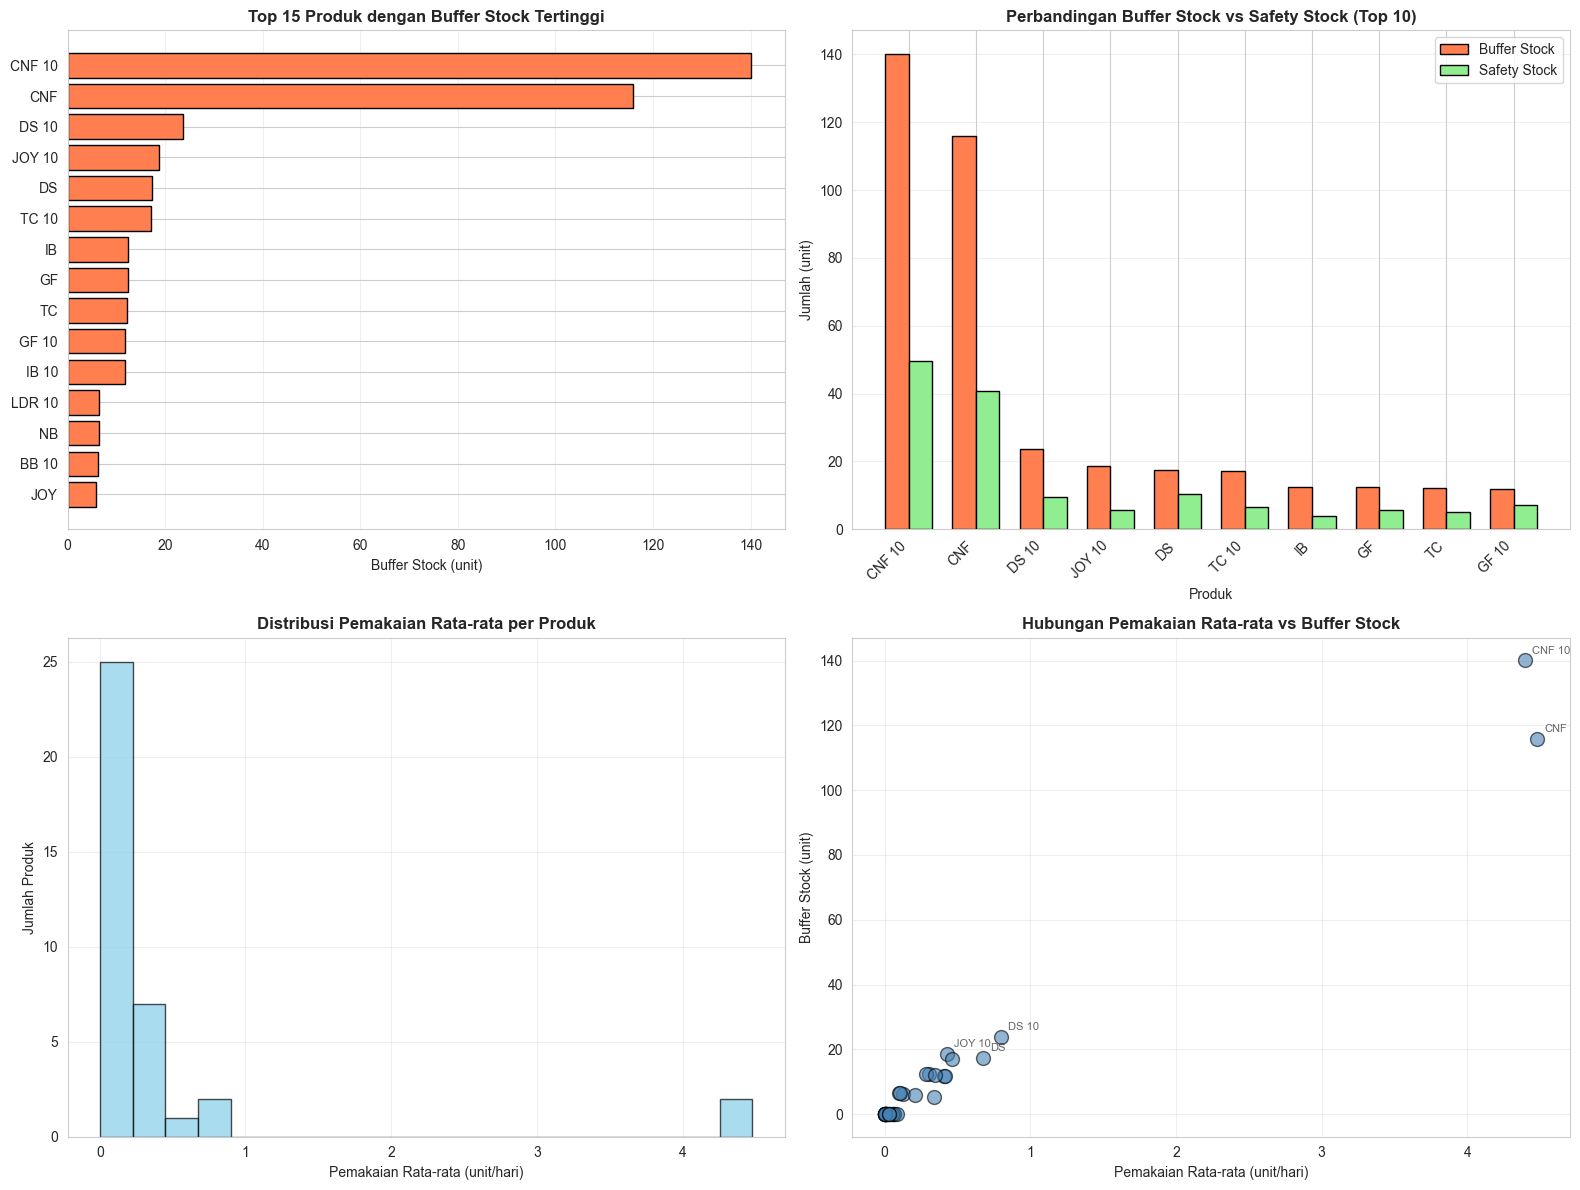

In [17]:
# Visualisasi Buffer Stock per Produk
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Top 15 Produk dengan Buffer Stock Tertinggi
top_15_buffer = product_stats.nlargest(15, 'Buffer_Stock').sort_values('Buffer_Stock', ascending=True)
axes[0, 0].barh(top_15_buffer['Produk'], top_15_buffer['Buffer_Stock'], color='coral', edgecolor='black')
axes[0, 0].set_title('Top 15 Produk dengan Buffer Stock Tertinggi', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Buffer Stock (unit)')
axes[0, 0].grid(True, axis='x', alpha=0.3)

# Plot 2: Perbandingan Buffer Stock vs Safety Stock (Top 10)
top_10_comparison = product_stats.nlargest(10, 'Buffer_Stock')
x_pos = np.arange(len(top_10_comparison))
width = 0.35

axes[0, 1].bar(x_pos - width/2, top_10_comparison['Buffer_Stock'], width, label='Buffer Stock', color='coral', edgecolor='black')
axes[0, 1].bar(x_pos + width/2, top_10_comparison['Safety_Stock_95%'], width, label='Safety Stock', color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Perbandingan Buffer Stock vs Safety Stock (Top 10)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Produk')
axes[0, 1].set_ylabel('Jumlah (unit)')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(top_10_comparison['Produk'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, axis='y', alpha=0.3)

# Plot 3: Distribusi Pemakaian Rata-rata per Produk
axes[1, 0].hist(product_stats['Pemakaian_Rata_rata'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribusi Pemakaian Rata-rata per Produk', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Pemakaian Rata-rata (unit/hari)')
axes[1, 0].set_ylabel('Jumlah Produk')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Scatter Plot - Pemakaian Rata-rata vs Buffer Stock
axes[1, 1].scatter(product_stats['Pemakaian_Rata_rata'], product_stats['Buffer_Stock'], 
                   s=100, alpha=0.6, c='steelblue', edgecolor='black')
axes[1, 1].set_title('Hubungan Pemakaian Rata-rata vs Buffer Stock', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Pemakaian Rata-rata (unit/hari)')
axes[1, 1].set_ylabel('Buffer Stock (unit)')
axes[1, 1].grid(True, alpha=0.3)

# Tambahkan label untuk produk dengan buffer stock tertinggi
top_5_label = product_stats.nlargest(5, 'Buffer_Stock')
for idx, row in top_5_label.iterrows():
    axes[1, 1].annotate(row['Produk'], 
                       (row['Pemakaian_Rata_rata'], row['Buffer_Stock']),
                       xytext=(5, 5), textcoords='offset points', 
                       fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

## 10. Ringkasan Hasil & Rekomendasi

In [18]:
# Ringkasan Statistik Keseluruhan
total_buffer_stock = product_stats['Buffer_Stock'].sum()
total_safety_stock = product_stats['Safety_Stock_95%'].sum()
avg_buffer_stock = product_stats['Buffer_Stock'].mean()

print("\n" + "=" * 80)
print("RINGKASAN HASIL PERHITUNGAN BUFFER STOCK")
print("=" * 80)
print(f"Rumus        : (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)")
print(f"Jumlah Produk Dianalisis        : {len(product_stats)} produk")
print(f"Avg Lead Time                   : {avg_lead_time} hari")
print(f"Max Lead Time                   : {max_lead_time} hari")
print(f"Total Buffer Stock (Semua Produk): {total_buffer_stock:.2f} unit")
print(f"Total Safety Stock (Semua Produk): {total_safety_stock:.2f} unit")
print(f"Rata-rata Buffer Stock per Produk: {avg_buffer_stock:.2f} unit")
print("=" * 80)

print("\n📊 TOP 10 PRODUK PRIORITAS UNTUK BUFFER STOCK:")
print("=" * 80)
top_10 = product_stats.nlargest(10, 'Buffer_Stock')[['Produk', 'Pemakaian_Rata_rata', 'Pemakaian_Maksimum', 'Buffer_Stock', 'Safety_Stock_95%']]
top_10_display = top_10.copy()
top_10_display.columns = ['Produk', 'Avg Daily Sales', 'Max Daily Sales', 'Buffer Stock', 'Safety Stock']
print(top_10_display.to_string(index=False))
print("=" * 80)

print("\n💡 REKOMENDASI:")
print("-" * 80)
print(f"1. Prioritaskan produk dengan buffer stock tertinggi untuk dijaga ketersediaannya")
print(f"2. Total buffer stock yang diperlukan untuk semua produk: {total_buffer_stock:.2f} unit")
print(f"3. Produk dengan buffer stock > {avg_buffer_stock:.0f} unit memerlukan perhatian khusus")
print(f"4. Tinjau ulang buffer stock secara berkala sesuai perubahan pola permintaan")
print("=" * 80)



RINGKASAN HASIL PERHITUNGAN BUFFER STOCK
Rumus        : (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)
Jumlah Produk Dianalisis        : 37 produk
Avg Lead Time                   : 5.4 hari
Max Lead Time                   : 7 hari
Total Buffer Stock (Semua Produk): 424.27 unit
Total Safety Stock (Semua Produk): 180.79 unit
Rata-rata Buffer Stock per Produk: 11.47 unit

📊 TOP 10 PRODUK PRIORITAS UNTUK BUFFER STOCK:
Produk  Avg Daily Sales  Max Daily Sales  Buffer Stock  Safety Stock
CNF 10         4.397260             23.4    140.054795     49.647762
   CNF         4.479452             20.0    115.810959     40.875977
 DS 10         0.800000              4.0     23.680000      9.422876
JOY 10         0.430137              3.0     18.677260      5.746000
    DS         0.676712              3.0     17.345753     10.290447
 TC 10         0.463014              2.8     17.099726      6.445924
    IB         0.282192              2.0     12.476164      3.802172
    GF

## 11. Export Hasil ke CSV

In [ ]:
# Siapkan dataframe untuk export dengan informasi lengkap
export_df = product_stats.copy()
export_df.columns = [
    'Produk',
    'Max_Daily_Sales',
    'Avg_Daily_Sales',
    'Standar_Deviasi',
    'Buffer_Stock_Unit',
    'Safety_Stock_95percent_Unit'
]

# Tambahkan informasi lead time ke dalam dataframe export
export_df['Avg_Lead_Time_Hari'] = avg_lead_time
export_df['Max_Lead_Time_Hari'] = max_lead_time

# Tambahkan kolom keterangan rumus
export_df['Rumus'] = f'(Max Daily Sales x {max_lead_time}) - (Avg Daily Sales x {avg_lead_time})'

# Urutkan berdasarkan buffer stock tertinggi
export_df = export_df.sort_values('Buffer_Stock_Unit', ascending=False)

# Round semua angka ke 2 desimal
numeric_columns = export_df.select_dtypes(include=[np.number]).columns
export_df[numeric_columns] = export_df[numeric_columns].round(2)

# Save to CSV
output_file = 'buffer_stock_per_produk.csv'
export_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"✅ Hasil analisis buffer stock per produk berhasil disimpan ke:")
print(f"   {output_file}")
print(f"\n📊 Total: {len(export_df)} produk")
print(f"\nPreview 10 produk teratas:")
print(export_df[['Produk', 'Avg_Daily_Sales', 'Max_Daily_Sales', 'Buffer_Stock_Unit']].head(10).to_string(index=False))


✅ Hasil analisis buffer stock per produk berhasil disimpan ke:
   buffer_stock_per_produk.csv

📊 Total: 37 produk

Preview 10 produk teratas:
Produk  Pemakaian_Rata_rata_per_Hari  Pemakaian_Maksimum_per_Hari  Buffer_Stock_Unit
CNF 10                          4.40                        134.0             648.01
   CNF                          4.48                         85.0             402.60
    DS                          0.68                         38.0             186.62
 GF 10                          0.41                         31.0             152.97
 IB 10                          0.41                         26.0             127.95
 DS 10                          0.80                         26.0             126.00
    GF                          0.30                         23.0             113.49
    CC                          0.34                         20.0              98.30
    TC                          0.35                         19.0              93.27
 TC 10  